# Age Regression with a CNN

This notebook walks through the project step by step. The actual code lives in `src/age_estimation/`, the notebook only calls it and shows the results.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

from age_estimation.config import DEFAULT_WEIGHTS, REPORTS_DIR, TrainConfig
from age_estimation.data import build_loader, download_dataset, load_file_names, split_data
from age_estimation.model import AgeCNN, get_device
from age_estimation.predict import predict_age
from age_estimation.train import evaluate, predict_all, train

device = get_device()
print(torch.__version__, device)

2.14.1+cu132 cuda


## 1. Data

Download UTKFace (only the first time) and read the age labels from the file names.

In [2]:
image_dir = download_dataset()
files, labels = load_file_names(image_dir)
print(f"{len(files)} images, ages {min(labels)} to {max(labels)}")

Data set already extracted.
23708 images, ages 1 to 116


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, i in zip(axes, np.random.default_rng(0).choice(len(files), 5, replace=False)):
    ax.imshow(plt.imread(files[i]))
    ax.set_title(f"Age: {labels[i]}")
    ax.axis("off")
plt.show()

Distribution of the labels. The data set is not balanced: there are many young adults and babies and few very old people.

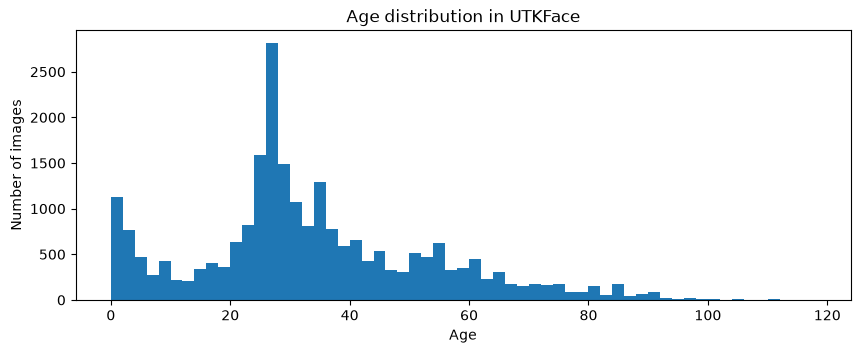

In [4]:
plt.figure(figsize=(10, 3.5))
plt.hist(labels, bins=range(0, 120, 2))
plt.xlabel("Age")
plt.ylabel("Number of images")
plt.title("Age distribution in UTKFace")
plt.show()

## 2. Train / validation / test split

In [5]:
config = TrainConfig(epochs=20)
torch.manual_seed(config.seed)

splits = split_data(files, labels, config.val_fraction, config.test_fraction, config.seed)
train_loader = build_loader(splits["train"], config.batch_size, shuffle=True, num_workers=config.num_workers)
val_loader = build_loader(splits["val"], config.batch_size, num_workers=config.num_workers)
test_loader = build_loader(splits["test"], config.batch_size, num_workers=config.num_workers)
{name: len(pairs) for name, pairs in splits.items()}

{'train': 18968, 'val': 2370, 'test': 2370}

## 3. Model

In [6]:
model = AgeCNN().to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(5, 5), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(4, 4))
    (3): ReLU()
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=2304, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 307,185


## 4. Training

The loss is the mean absolute error, i.e. by how many years the prediction is off on average.

In [7]:
history = train(model, train_loader, val_loader, config, device)

Epoch  1/20  train MAE: 16.29  val MAE: 14.11
Epoch  2/20  train MAE: 14.26  val MAE: 12.95
Epoch  3/20  train MAE: 12.95  val MAE: 13.71
Epoch  4/20  train MAE: 11.98  val MAE: 11.18
Epoch  5/20  train MAE: 11.04  val MAE: 12.50
Epoch  6/20  train MAE: 10.46  val MAE: 13.55
Epoch  7/20  train MAE: 9.82  val MAE: 9.34
Epoch  8/20  train MAE: 9.40  val MAE: 10.23
Epoch  9/20  train MAE: 9.05  val MAE: 9.61
Epoch 10/20  train MAE: 8.75  val MAE: 8.75
Epoch 11/20  train MAE: 8.51  val MAE: 8.28
Epoch 12/20  train MAE: 8.35  val MAE: 8.43
Epoch 13/20  train MAE: 8.17  val MAE: 8.54
Epoch 14/20  train MAE: 8.01  val MAE: 8.83
Epoch 15/20  train MAE: 7.90  val MAE: 7.97
Epoch 16/20  train MAE: 7.79  val MAE: 7.82
Epoch 17/20  train MAE: 7.63  val MAE: 7.60
Epoch 18/20  train MAE: 7.53  val MAE: 7.43
Epoch 19/20  train MAE: 7.46  val MAE: 7.62
Epoch 20/20  train MAE: 7.30  val MAE: 7.92


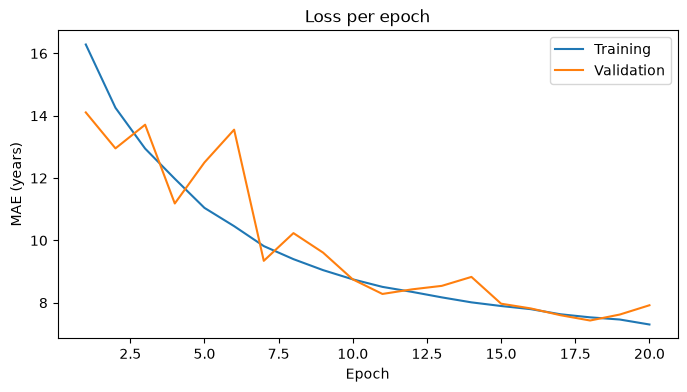

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history["train_loss"], label="Training")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MAE (years)")
plt.title("Loss per epoch")
plt.legend()
plt.show()

## 5. Evaluation on the test set

As a reference: a model that always predicts the median age of the training data.

In [9]:
preds, true = predict_all(model, test_loader, device)
test_mae = (preds - true).abs().mean().item()

train_ages = np.array([age for _, age in splits["train"]])
baseline_mae = np.abs(true.numpy() - np.median(train_ages)).mean()

print(f"Test MAE:     {test_mae:.2f} years")
print(f"Baseline MAE: {baseline_mae:.2f} years (always predicting the median age)")

Test MAE:     7.58 years
Baseline MAE: 15.42 years (always predicting the median age)


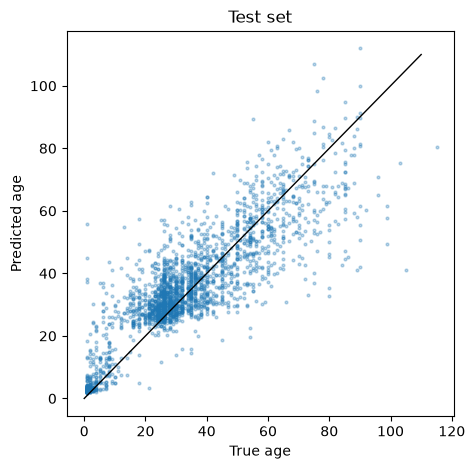

In [10]:
# Predicted vs. true age
plt.figure(figsize=(5, 5))
plt.scatter(true, preds, s=4, alpha=0.3)
plt.plot([0, 110], [0, 110], color="black", linewidth=1)
plt.xlabel("True age")
plt.ylabel("Predicted age")
plt.title("Test set")
plt.show()

## 6. Save the model and predict single images

In [11]:
DEFAULT_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), DEFAULT_WEIGHTS)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
(REPORTS_DIR / "history.json").write_text(json.dumps({**history, "test_loss": test_mae}, indent=2))

1002

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (path, age) in zip(axes, splits["test"][:5]):
    ax.imshow(plt.imread(path))
    ax.set_title(f"True: {age}  Predicted: {predict_age(model, path):.0f}")
    ax.axis("off")
plt.show()

To try your own picture (a square portrait with the face in the centre works best):

```python
predict_age(model, "path/to/your_image.jpg")
```